CLAIM_ID
POLICY_ID
CUSTOMER_ID
CLAIM_TYPE
INCIDENT_DATE
REPORTED_DATE
CLAIM_AMOUNT
CLAIM_STATUS
SETTLEMENT_AMOUNT
PROCESSING_DAYS
FRAUD_FLAG
FRAUD_SCORE
SOURCE
CLAIM_SEVERITY

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)

In [3]:
PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data" / "raw"

claims_df = pd.read_csv(
    DATA_DIR / "claims.csv"
)

policies_df = pd.read_csv(
    DATA_DIR / "policies.csv"
)

print("Claims   :", claims_df.shape)
print("Policies :", policies_df.shape)

Claims   : (75000, 14)
Policies : (150000, 15)


In [4]:
claims_df.head()

,CLAIM_ID,POLICY_ID,CUSTOMER_ID,CLAIM_TYPE,INCIDENT_DATE,REPORTED_DATE,CLAIM_AMOUNT,CLAIM_STATUS,SETTLEMENT_AMOUNT,PROCESSING_DAYS,FRAUD_FLAG,FRAUD_SCORE,SOURCE,CLAIM_SEVERITY
0,CLM000000001,POL000041446,CUST00025025,Vehicle Damage,2022-03-22,2022-03-24,1048663,Approved,1047821,30,No,0.1639,Surveyor,Medium
1,CLM000000002,POL000087254,CUST00082211,Theft,2026-06-26,2026-07-03,6584,Under Investigation,0,33,No,0.2701,Garage,Low
2,CLM000000003,POL000058180,CUST00020965,Death,2024-05-12,2024-05-18,109923,Approved,103624,18,No,0.2997,Surveyor,Low
3,CLM000000004,POL000105789,CUST00014259,Liability,2025-12-14,2025-12-20,276770,Approved,251398,12,No,0.8973,Hospital,Low
4,CLM000000005,POL000117667,CUST00067498,Travel Disruption,2022-11-18,2022-11-19,39463,Approved,39286,14,No,0.2776,Police,Medium


In [5]:
claims_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CLAIM_ID           75000 non-null  str    
 1   POLICY_ID          75000 non-null  str    
 2   CUSTOMER_ID        75000 non-null  str    
 3   CLAIM_TYPE         75000 non-null  str    
 4   INCIDENT_DATE      75000 non-null  str    
 5   REPORTED_DATE      75000 non-null  str    
 6   CLAIM_AMOUNT       75000 non-null  int64  
 7   CLAIM_STATUS       75000 non-null  str    
 8   SETTLEMENT_AMOUNT  75000 non-null  int64  
 9   PROCESSING_DAYS    75000 non-null  int64  
 10  FRAUD_FLAG         75000 non-null  str    
 11  FRAUD_SCORE        75000 non-null  float64
 12  SOURCE             75000 non-null  str    
 13  CLAIM_SEVERITY     75000 non-null  str    
dtypes: float64(1), int64(3), str(10)
memory usage: 8.0 MB


In [6]:
claims_df["INCIDENT_DATE"] = pd.to_datetime(
    claims_df["INCIDENT_DATE"],
    errors="coerce"
)

claims_df["REPORTED_DATE"] = pd.to_datetime(
    claims_df["REPORTED_DATE"],
    errors="coerce"
)

In [8]:
total_claims = claims_df["CLAIM_ID"].nunique()

policies_with_claims = claims_df[
    "POLICY_ID"
].nunique()

total_claim_amount = claims_df[
    "CLAIM_AMOUNT"
].sum()

total_settlement_amount = claims_df[
    "SETTLEMENT_AMOUNT"
].sum()

avg_claim_amount = claims_df[
    "CLAIM_AMOUNT"
].mean()

median_claim_amount = claims_df[
    "CLAIM_AMOUNT"
].median()

avg_processing_days = claims_df[
    "PROCESSING_DAYS"
].mean()

In [9]:
print("Total Claims:", total_claims)

print(
    "Policies with Claims:",
    policies_with_claims
)

print(
    "Total Claim Amount:",
    total_claim_amount
)

print(
    "Total Settlement Amount:",
    total_settlement_amount
)

print(
    "Average Claim Amount:",
    round(avg_claim_amount, 2)
)

print(
    "Median Claim Amount:",
    round(median_claim_amount, 2)
)

print(
    "Average Processing Days:",
    round(avg_processing_days, 2)
)

Total Claims: 75000
Policies with Claims: 58905
Total Claim Amount: 22976134565
Total Settlement Amount: 14755056069
Average Claim Amount: 306348.46
Median Claim Amount: 109064.5
Average Processing Days: 20.51


In [10]:
claim_policy_pct = (
    policies_with_claims
    /
    policies_df["POLICY_ID"].nunique()
    * 100
)

print(
    round(claim_policy_pct, 2),
    "%"
)

39.27 %


In [11]:
avg_claims_per_claim_policy = (
    total_claims
    /
    policies_with_claims
)

print(
    round(
        avg_claims_per_claim_policy,
        2
    )
)

1.27


Claim Status Analysis

In [12]:
claim_status_summary = (
    claims_df["CLAIM_STATUS"]
    .value_counts()
    .to_frame("CLAIM_COUNT")
)

claim_status_summary[
    "PERCENTAGE"
] = (
    claim_status_summary[
        "CLAIM_COUNT"
    ]
    /
    len(claims_df)
    * 100
)

claim_status_summary

,CLAIM_COUNT,PERCENTAGE
CLAIM_STATUS,,
Approved,49984,66.645333
Pending,7553,10.070667
Rejected,6315,8.420000
Partially Approved,6006,8.008000
Under Investigation,5142,6.856000


| Claim Status        | Approx. % |
| ------------------- | --------: |
| Approved            |    66.65% |
| Pending             |    10.07% |
| Rejected            |     8.42% |
| Partially Approved  |     8.01% |
| Under Investigation |     6.86% |


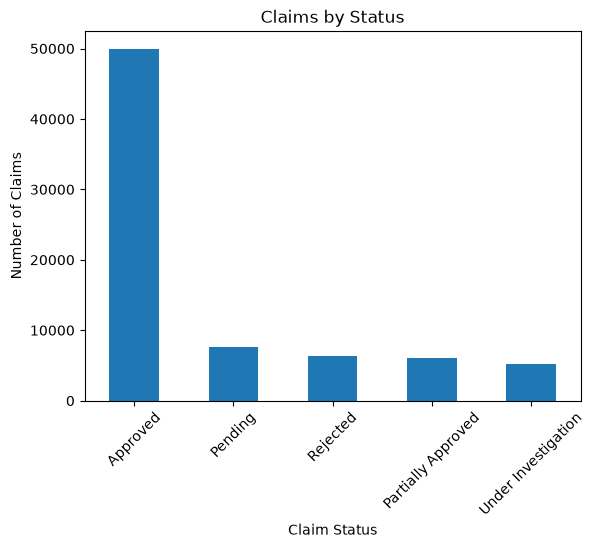

In [13]:
claim_status_summary[
    "CLAIM_COUNT"
].plot(
    kind="bar"
)

plt.title("Claims by Status")
plt.xlabel("Claim Status")
plt.ylabel("Number of Claims")
plt.xticks(rotation=45)
plt.show()

Claim Severity

In [14]:
severity_summary = (
    claims_df[
        "CLAIM_SEVERITY"
    ]
    .value_counts()
    .to_frame("CLAIMS")
)

severity_summary[
    "PERCENTAGE"
] = (
    severity_summary["CLAIMS"]
    /
    len(claims_df)
    * 100
)

severity_summary

,CLAIMS,PERCENTAGE
CLAIM_SEVERITY,,
Low,40688,54.250667
Medium,26854,35.805333
High,7458,9.944000


In [15]:
severity_amount_summary = (
    claims_df
    .groupby("CLAIM_SEVERITY")
    .agg(
        CLAIM_COUNT=(
            "CLAIM_ID",
            "count"
        ),

        AVG_CLAIM_AMOUNT=(
            "CLAIM_AMOUNT",
            "mean"
        ),

        TOTAL_CLAIM_AMOUNT=(
            "CLAIM_AMOUNT",
            "sum"
        ),

        AVG_PROCESSING_DAYS=(
            "PROCESSING_DAYS",
            "mean"
        )
    )
    .reset_index()
)

severity_amount_summary

,CLAIM_SEVERITY,CLAIM_COUNT,AVG_CLAIM_AMOUNT,TOTAL_CLAIM_AMOUNT,AVG_PROCESSING_DAYS
0,High,7458,317083.696165,2364810206,20.477474
1,Low,40688,303827.155722,12362119312,20.565351
2,Medium,26854,307187.199188,8249205047,20.440903


In [16]:
settlement_ratio = (
    total_settlement_amount
    /
    total_claim_amount
    * 100
)

print(
    "Settlement Ratio:",
    round(settlement_ratio, 2),
    "%"
)

Settlement Ratio: 64.22 %


Settlement by Claim Status

In [17]:
status_financial_summary = (
    claims_df
    .groupby("CLAIM_STATUS")
    .agg(
        CLAIM_COUNT=(
            "CLAIM_ID",
            "count"
        ),

        TOTAL_CLAIM_AMOUNT=(
            "CLAIM_AMOUNT",
            "sum"
        ),

        TOTAL_SETTLEMENT=(
            "SETTLEMENT_AMOUNT",
            "sum"
        ),

        AVG_CLAIM_AMOUNT=(
            "CLAIM_AMOUNT",
            "mean"
        ),

        AVG_SETTLEMENT=(
            "SETTLEMENT_AMOUNT",
            "mean"
        ),

        AVG_PROCESSING_DAYS=(
            "PROCESSING_DAYS",
            "mean"
        )
    )
    .reset_index()
)

In [18]:
status_financial_summary[
    "SETTLEMENT_RATIO_PCT"
] = (
    status_financial_summary[
        "TOTAL_SETTLEMENT"
    ]
    /
    status_financial_summary[
        "TOTAL_CLAIM_AMOUNT"
    ]
    * 100
)

In [19]:
status_financial_summary.sort_values(
    "CLAIM_COUNT",
    ascending=False
)

,CLAIM_STATUS,CLAIM_COUNT,TOTAL_CLAIM_AMOUNT,TOTAL_SETTLEMENT,AVG_CLAIM_AMOUNT,AVG_SETTLEMENT,AVG_PROCESSING_DAYS,SETTLEMENT_RATIO_PCT
0,Approved,49984,15270935068,13754517395,305516.466629,275178.404990,20.481094,90.069909
2,Pending,7553,2321565466,0,307369.980935,0.000000,20.454919,0.000000
3,Rejected,6315,1957094101,0,309911.971655,0.000000,20.710847,0.000000
1,Partially Approved,6006,1837897571,1000538674,306010.251582,166589.855811,20.570430,54.439306
4,Under Investigation,5142,1588642359,0,308954.173279,0.000000,20.584597,0.000000


Claim Type Analysis

Your data contains claim types such as:

Accident
Hospitalization
Vehicle Damage
Theft
Travel Disruption
Liability
Death
Property Damage

In [20]:
claim_type_summary = (
    claims_df
    .groupby("CLAIM_TYPE")
    .agg(
        CLAIM_COUNT=(
            "CLAIM_ID",
            "count"
        ),

        TOTAL_CLAIM_AMOUNT=(
            "CLAIM_AMOUNT",
            "sum"
        ),

        AVG_CLAIM_AMOUNT=(
            "CLAIM_AMOUNT",
            "mean"
        ),

        AVG_PROCESSING_DAYS=(
            "PROCESSING_DAYS",
            "mean"
        )
    )
    .reset_index()
)

Reporting Delay

In [21]:
claims_df[
    "REPORTING_DELAY_DAYS"
] = (
    claims_df["REPORTED_DATE"]
    -
    claims_df["INCIDENT_DATE"]
).dt.days

In [22]:
claims_df[
    "REPORTING_DELAY_DAYS"
].describe()

count    75000.000000
mean         5.534213
std          4.258335
min          0.000000
25%          2.000000
50%          5.000000
75%          8.000000
max         51.000000
Name: REPORTING_DELAY_DAYS, dtype: float64

Large reporting delays can matter because they may affect:

Investigation
Documentation
Fraud detection
Claim handling
Customer experience

Processing Time

In [23]:
claims_df[
    "PROCESSING_DAYS"
].describe()

count    75000.000000
mean        20.512053
std         12.152669
min          1.000000
25%         12.000000
50%         18.000000
75%         27.000000
max        120.000000
Name: PROCESSING_DAYS, dtype: float64

In [24]:
claims_df[
    "PROCESSING_BUCKET"
] = pd.cut(
    claims_df[
        "PROCESSING_DAYS"
    ],
    bins=[
        0,
        7,
        15,
        30,
        60,
        float("inf")
    ],
    labels=[
        "0-7 Days",
        "8-15 Days",
        "16-30 Days",
        "31-60 Days",
        "60+ Days"
    ]
)

In [25]:
claims_df[
    "PROCESSING_BUCKET"
].value_counts().sort_index()

PROCESSING_BUCKET
0-7 Days       8178
8-15 Days     21838
16-30 Days    31288
31-60 Days    13119
60+ Days        577
Name: count, dtype: int64

Fraud Analysis

In [26]:
fraud_summary = (
    claims_df[
        "FRAUD_FLAG"
    ]
    .value_counts()
    .to_frame("CLAIMS")
)

fraud_summary[
    "PERCENTAGE"
] = (
    fraud_summary["CLAIMS"]
    /
    len(claims_df)
    * 100
)

fraud_summary

,CLAIMS,PERCENTAGE
FRAUD_FLAG,,
No,72841,97.121333
Suspected,1815,2.420000
Confirmed,344,0.458667


Do NOT Combine Suspected and Confirmed Conceptually

These mean different things.

Suspected

Potential fraud requiring investigation.

Confirmed

Fraud has been established according to the dataset's classification.

Fraud Score vs Fraud Flag

In [27]:
fraud_score_summary = (
    claims_df
    .groupby("FRAUD_FLAG")
    ["FRAUD_SCORE"]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
)

fraud_score_summary

,count,mean,median,min,max
FRAUD_FLAG,,,,,
Confirmed,344,0.519148,0.5299,0.0024,0.9965
No,72841,0.498087,0.4983,0.0000,1.0000
Suspected,1815,0.505744,0.5025,0.0017,0.9995


They're extremely similar.

This means FRAUD_SCORE does not strongly separate the fraud classes in this synthetic dataset.

Fraud by Claim Type

In [28]:
claims_df[
    "FRAUD_ALERT"
] = claims_df[
    "FRAUD_FLAG"
].isin(
    ["Suspected", "Confirmed"]
).astype(int)

In [29]:
fraud_by_type = (
    claims_df
    .groupby("CLAIM_TYPE")
    .agg(
        TOTAL_CLAIMS=(
            "CLAIM_ID",
            "count"
        ),

        FRAUD_ALERTS=(
            "FRAUD_ALERT",
            "sum"
        )
    )
    .reset_index()
)

In [30]:
fraud_by_type[
    "FRAUD_ALERT_RATE"
] = (
    fraud_by_type[
        "FRAUD_ALERTS"
    ]
    /
    fraud_by_type[
        "TOTAL_CLAIMS"
    ]
    * 100
)

In [31]:
fraud_by_type.sort_values(
    "FRAUD_ALERT_RATE",
    ascending=False
)

,CLAIM_TYPE,TOTAL_CLAIMS,FRAUD_ALERTS,FRAUD_ALERT_RATE
2,Hospitalization,9461,298,3.149773
0,Accident,9515,294,3.089858
7,Vehicle Damage,9421,266,2.823479
1,Death,9300,262,2.817204
4,Property Damage,9278,261,2.813106
6,Travel Disruption,9335,261,2.795929
5,Theft,9375,261,2.784000
3,Liability,9315,256,2.748256


Merge Claims with Policy

Which insurance products generate the most claims?

In [32]:
claim_policy_df = claims_df.merge(
    policies_df[
        [
            "POLICY_ID",
            "POLICY_TYPE",
            "ANNUAL_PREMIUM",
            "SUM_INSURED",
            "RISK_SCORE",
            "RISK_BAND"
        ]
    ],
    on="POLICY_ID",
    how="left",
    validate="many_to_one"
)

In [34]:
claim_policy_df.shape

(75000, 22)

Claims by Policy Type

In [35]:
product_claim_summary = (
    claim_policy_df
    .groupby("POLICY_TYPE")
    .agg(
        CLAIM_COUNT=(
            "CLAIM_ID",
            "count"
        ),

        CLAIMING_POLICIES=(
            "POLICY_ID",
            "nunique"
        ),

        TOTAL_CLAIM_AMOUNT=(
            "CLAIM_AMOUNT",
            "sum"
        ),

        TOTAL_SETTLEMENT=(
            "SETTLEMENT_AMOUNT",
            "sum"
        ),

        AVG_CLAIM_AMOUNT=(
            "CLAIM_AMOUNT",
            "mean"
        ),

        AVG_PROCESSING_DAYS=(
            "PROCESSING_DAYS",
            "mean"
        )
    )
    .reset_index()
)

In [36]:
product_claim_summary[
    "SETTLEMENT_RATIO_PCT"
] = (
    product_claim_summary[
        "TOTAL_SETTLEMENT"
    ]
    /
    product_claim_summary[
        "TOTAL_CLAIM_AMOUNT"
    ]
    * 100
)

In [37]:
product_claim_summary.sort_values(
    "CLAIM_COUNT",
    ascending=False
)

,POLICY_TYPE,CLAIM_COUNT,CLAIMING_POLICIES,TOTAL_CLAIM_AMOUNT,TOTAL_SETTLEMENT,AVG_CLAIM_AMOUNT,AVG_PROCESSING_DAYS,SETTLEMENT_RATIO_PCT
1,Health,18168,14230,1717479475,1108767595,94533.216369,20.439729,64.557837
3,Motor,15784,12448,1296489739,830071609,82139.491827,20.663393,64.024541
5,Term Life,12004,9459,8140750952,5238127433,678169.856048,20.467261,64.344524
0,Commercial,7451,5857,6116453161,3902488531,820890.237686,20.554959,63.803129
4,Personal Accident,5996,4661,959314923,619914838,159992.482155,20.587892,64.620577
2,Home,5944,4671,2825820097,1818482102,475407.149563,20.525908,64.352366
7,Whole Life,5172,4058,1728004278,1113526156,334107.555684,20.356342,64.440012
6,Travel,4481,3521,191821940,123677805,42807.842000,20.380719,64.475318


In [38]:
claims_df[
    "APPROVED_FLAG"
] = (
    claims_df[
        "CLAIM_STATUS"
    ] == "Approved"
).astype(int)

In [39]:
claims_df[
    "PARTIAL_APPROVED_FLAG"
] = (
    claims_df[
        "CLAIM_STATUS"
    ] == "Partially Approved"
).astype(int)

In [40]:
claims_df[
    "REJECTED_FLAG"
] = (
    claims_df[
        "CLAIM_STATUS"
    ] == "Rejected"
).astype(int)

In [41]:
claims_df[
    "PENDING_FLAG"
] = (
    claims_df[
        "CLAIM_STATUS"
    ] == "Pending"
).astype(int)

In [42]:
claims_df[
    "UNDER_INVESTIGATION_FLAG"
] = (
    claims_df[
        "CLAIM_STATUS"
    ] == "Under Investigation"
).astype(int)

In [44]:
claims_df[
    "SUSPECTED_FRAUD_FLAG"
] = (
    claims_df[
        "FRAUD_FLAG"
    ] == "Suspected"
).astype(int)

In [45]:
claims_df[
    "CONFIRMED_FRAUD_FLAG"
] = (
    claims_df[
        "FRAUD_FLAG"
    ] == "Confirmed"
).astype(int)

In [46]:
claims_df[
    "HIGH_SEVERITY_FLAG"
] = (
    claims_df[
        "CLAIM_SEVERITY"
    ] == "High"
).astype(int)

In [47]:
policy_claim_features = (
    claims_df
    .groupby(
        [
            "POLICY_ID",
            "CUSTOMER_ID"
        ]
    )
    .agg(
        TOTAL_CLAIMS=(
            "CLAIM_ID",
            "count"
        ),

        TOTAL_CLAIM_AMOUNT=(
            "CLAIM_AMOUNT",
            "sum"
        ),

        TOTAL_SETTLEMENT_AMOUNT=(
            "SETTLEMENT_AMOUNT",
            "sum"
        ),

        AVG_CLAIM_AMOUNT=(
            "CLAIM_AMOUNT",
            "mean"
        ),

        MAX_CLAIM_AMOUNT=(
            "CLAIM_AMOUNT",
            "max"
        ),

        AVG_PROCESSING_DAYS=(
            "PROCESSING_DAYS",
            "mean"
        ),

        MAX_PROCESSING_DAYS=(
            "PROCESSING_DAYS",
            "max"
        ),

        AVG_REPORTING_DELAY_DAYS=(
            "REPORTING_DELAY_DAYS",
            "mean"
        ),

        APPROVED_CLAIM_COUNT=(
            "APPROVED_FLAG",
            "sum"
        ),

        PARTIAL_APPROVED_CLAIM_COUNT=(
            "PARTIAL_APPROVED_FLAG",
            "sum"
        ),

        REJECTED_CLAIM_COUNT=(
            "REJECTED_FLAG",
            "sum"
        ),

        PENDING_CLAIM_COUNT=(
            "PENDING_FLAG",
            "sum"
        ),

        UNDER_INVESTIGATION_COUNT=(
            "UNDER_INVESTIGATION_FLAG",
            "sum"
        ),

        SUSPECTED_FRAUD_COUNT=(
            "SUSPECTED_FRAUD_FLAG",
            "sum"
        ),

        CONFIRMED_FRAUD_COUNT=(
            "CONFIRMED_FRAUD_FLAG",
            "sum"
        ),

        HIGH_SEVERITY_CLAIM_COUNT=(
            "HIGH_SEVERITY_FLAG",
            "sum"
        ),

        AVG_FRAUD_SCORE=(
            "FRAUD_SCORE",
            "mean"
        ),

        LAST_CLAIM_DATE=(
            "INCIDENT_DATE",
            "max"
        )
    )
    .reset_index()
)

In [48]:
policy_claim_features[
    "CLAIM_SETTLEMENT_RATIO"
] = np.where(
    policy_claim_features[
        "TOTAL_CLAIM_AMOUNT"
    ] > 0,

    policy_claim_features[
        "TOTAL_SETTLEMENT_AMOUNT"
    ]
    /
    policy_claim_features[
        "TOTAL_CLAIM_AMOUNT"
    ],

    0
)

In [49]:
policy_claim_features[
    "HAS_FRAUD_ALERT"
] = (
    (
        policy_claim_features[
            "SUSPECTED_FRAUD_COUNT"
        ]
        +
        policy_claim_features[
            "CONFIRMED_FRAUD_COUNT"
        ]
    ) > 0
).astype(int)

In [50]:
policy_claim_features.head()

,POLICY_ID,CUSTOMER_ID,TOTAL_CLAIMS,TOTAL_CLAIM_AMOUNT,TOTAL_SETTLEMENT_AMOUNT,AVG_CLAIM_AMOUNT,MAX_CLAIM_AMOUNT,AVG_PROCESSING_DAYS,MAX_PROCESSING_DAYS,AVG_REPORTING_DELAY_DAYS,APPROVED_CLAIM_COUNT,PARTIAL_APPROVED_CLAIM_COUNT,REJECTED_CLAIM_COUNT,PENDING_CLAIM_COUNT,UNDER_INVESTIGATION_COUNT,SUSPECTED_FRAUD_COUNT,CONFIRMED_FRAUD_COUNT,HIGH_SEVERITY_CLAIM_COUNT,AVG_FRAUD_SCORE,LAST_CLAIM_DATE,CLAIM_SETTLEMENT_RATIO,HAS_FRAUD_ALERT
0,POL000000001,CUST00047547,1,56858,0,56858.0,56858,16.0,16,6.0,0,0,1,0,0,0,0,0,0.5121,2022-07-06,0.000000,0
1,POL000000004,CUST00043802,1,32445,32429,32445.0,32445,15.0,15,4.0,1,0,0,0,0,0,0,0,0.0651,2026-08-22,0.999507,0
2,POL000000006,CUST00095870,1,269957,235488,269957.0,269957,33.0,33,6.0,1,0,0,0,0,0,0,0,0.6404,2023-05-26,0.872317,0
3,POL000000007,CUST00036618,1,132760,107245,132760.0,132760,27.0,27,5.0,1,0,0,0,0,0,0,0,0.4402,2022-11-21,0.807811,0
4,POL000000008,CUST00065718,1,429343,377229,429343.0,429343,4.0,4,7.0,1,0,0,0,0,0,0,0,0.4566,2025-11-28,0.878619,0


In [51]:
policy_claim_features[
    "POLICY_ID"
].duplicated().sum()

np.int64(0)

In [52]:
policy_claim_features.shape

(58905, 22)

In [53]:
PROCESSED_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [54]:
policy_claim_features.to_csv(
    PROCESSED_DIR
    / "policy_claim_features.csv",
    index=False
)

75K Claims
     ↓
58.9K Policies represented
     ↓
~66.6% Approved
     ↓
~₹3.06L average claim
but only ~₹1.09L median
     ↓
Claims are strongly right-skewed
     ↓
~20.5 days average processing
     ↓
~2.42% Suspected Fraud
~0.46% Confirmed Fraud
     ↓
Fraud Score does not strongly
separate fraud classes
     ↓
Policy-level claim features created